# Patient Risk Clustering using K-Means and Gaussian Mixture Model (GMM)

## Objective

The objective of this notebook is to identify hidden patient groups (risk tiers) using unsupervised learning techniques.

Unlike supervised learning, clustering does not use the target variable (`cardio`). Instead, it groups patients based on similarities in their clinical characteristics.

The clustering results will help identify:

- Low Risk Population
- Moderate Risk Population
- High Risk Population

Algorithms Used:

- K-Means Clustering
- Gaussian Mixture Model (GMM)

Evaluation Techniques:

- Elbow Method
- Silhouette Score

Final Output:

- Population Risk Dashboard
- Cluster Profiling
- Risk Tier Analysis

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("cardio_cleaned.csv")

In [3]:
print("Dataset Shape")
print(df.shape)

print()

print("First Five Rows")

display(df.head())

print()

print("Columns")

print(df.columns.tolist())

Dataset Shape
(68748, 13)

First Five Rows


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177



Columns
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'BMI']


In [4]:
print("Dataset Information")

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68748 entries, 0 to 68747
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          68748 non-null  int64  
 1   gender       68748 non-null  int64  
 2   height       68748 non-null  int64  
 3   weight       68748 non-null  float64
 4   ap_hi        68748 non-null  int64  
 5   ap_lo        68748 non-null  int64  
 6   cholesterol  68748 non-null  int64  
 7   gluc         68748 non-null  int64  
 8   smoke        68748 non-null  int64  
 9   alco         68748 non-null  int64  
 10  active       68748 non-null  int64  
 11  cardio       68748 non-null  int64  
 12  BMI          68748 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 6.8 MB


In [5]:
print("Statistical Summary")

display(df.describe())

Statistical Summary


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
count,68748.000000,68748.000000,68748.000000,68748.000000,68748.000000,68748.000000,68748.000000,68748.000000,68748.000000,68748.000000,68748.000000,68748.000000,68748.000000
mean,52.828679,1.348723,164.395313,74.124148,126.616934,81.377829,1.364782,1.226072,0.087988,0.053631,0.803383,0.494923,27.474740
std,6.768784,0.476570,7.978740,14.306593,16.764231,9.688164,0.679009,0.572044,0.283280,0.225289,0.397443,0.499978,5.350847
min,29.000000,1.000000,100.000000,30.000000,60.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10.726644
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.346494
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.119376
max,64.000000,2.000000,207.000000,200.000000,240.000000,190.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,152.551775


In [6]:
print("Missing Values")

display(df.isnull().sum())

Missing Values


age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
BMI            0
dtype: int64

In [7]:
X = df.drop(columns=["cardio"])

print("Feature Matrix Shape :", X.shape)

print()

print("Selected Features")

print(X.columns.tolist())

Feature Matrix Shape : (68748, 12)

Selected Features
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Shape :", X_scaled.shape)

Scaled Shape : (68748, 12)


In [9]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

scaled_df.describe().round(2)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
count,68748.00,68748.00,68748.00,68748.00,68748.00,68748.00,68748.00,68748.0,68748.00,68748.00,68748.00,68748.00
mean,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.0,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00
min,-3.52,-0.73,-8.07,-3.08,-3.97,-5.30,-0.54,-0.4,-0.31,-0.24,-2.02,-3.13
25%,-0.71,-0.73,-0.68,-0.64,-0.39,-0.14,-0.54,-0.4,-0.31,-0.24,0.49,-0.67
50%,0.03,-0.73,0.08,-0.15,-0.39,-0.14,-0.54,-0.4,-0.31,-0.24,0.49,-0.21
75%,0.76,1.37,0.70,0.55,0.80,0.89,0.94,-0.4,-0.31,-0.24,0.49,0.49
max,1.65,1.37,5.34,8.80,6.76,11.21,2.41,3.1,3.22,4.20,0.49,23.38


# Finding the Optimal Number of Clusters

## Objective

Before applying K-Means clustering, the optimal number of clusters (K) must be determined.

The Elbow Method evaluates different values of K by calculating the Within-Cluster Sum of Squares (WCSS).

The optimal K is selected where adding more clusters results in only a small reduction in WCSS, forming an "elbow" in the graph.

In [10]:
wcss = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

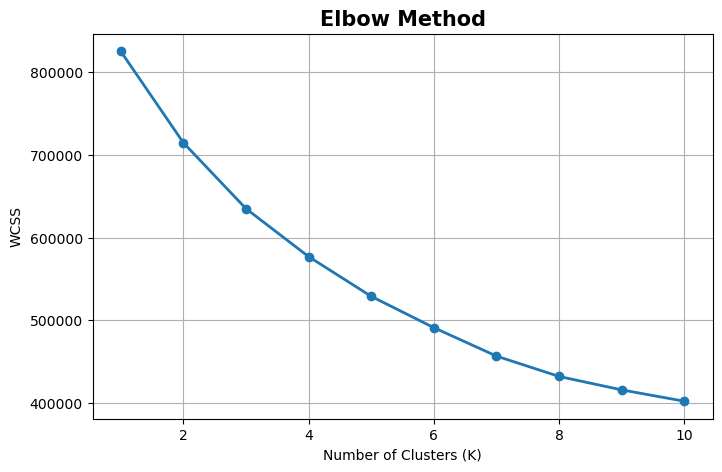

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    wcss,
    marker="o",
    linewidth=2
)

plt.title(
    "Elbow Method",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [12]:
elbow_df = pd.DataFrame({
    "K": list(K),
    "WCSS": wcss
})

elbow_df

,K,WCSS
0,1,824976.000000
1,2,714538.079345
2,3,634927.451904
3,4,576996.419212
4,5,529020.984486
5,6,491208.343223
6,7,456894.420871
7,8,432297.465546
8,9,416081.698710
9,10,402391.656363


# Silhouette Score

The Silhouette Score measures how well each patient fits within its assigned cluster compared to other clusters.

Higher values indicate better-defined and well-separated clusters.

The value ranges from:

- +1 → Excellent clustering
- 0 → Overlapping clusters
- -1 → Incorrect clustering

In [14]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    labels,
    sample_size=10000,
    random_state=42
)

In [15]:
silhouette_scores = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)

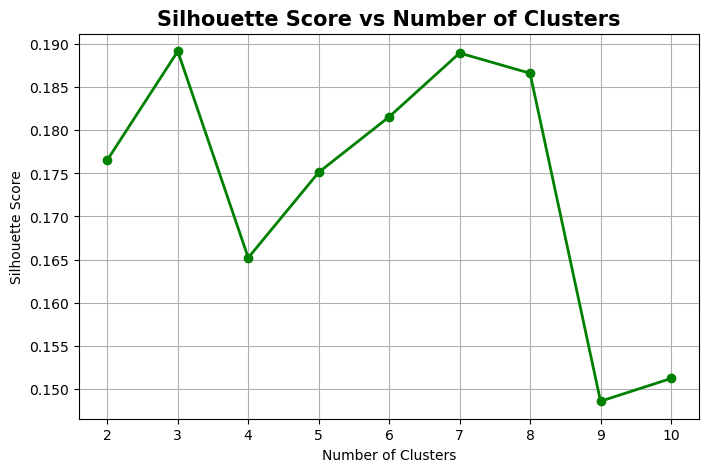

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    silhouette_scores,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title(
    "Silhouette Score vs Number of Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

In [17]:
silhouette_df = pd.DataFrame({
    "K": list(K),
    "Silhouette Score": silhouette_scores
})

silhouette_df

,K,Silhouette Score
0,2,0.176556
1,3,0.189181
2,4,0.165208
3,5,0.175127
4,6,0.181565
5,7,0.188972
6,8,0.186624
7,9,0.148554
8,10,0.151192


# Optimal Number of Clusters

Two evaluation methods were used to determine the optimal number of clusters.

### Elbow Method

The WCSS decreased rapidly from K=1 to K=3 and then began to level off, indicating an elbow around K=3.

### Silhouette Score

The highest Silhouette Score was obtained for K=3, indicating the best balance between cluster cohesion and separation.

### Final Decision

Based on both the Elbow Method and the Silhouette Score, K=3 was selected as the optimal number of clusters.

This also aligns with the project objective of identifying three patient risk tiers:

- Low Risk
- Moderate Risk
- High Risk

In [18]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataset
df["Cluster"] = cluster_labels

print("Cluster labels added successfully!")

print()

print(df["Cluster"].value_counts().sort_index())

Cluster labels added successfully!

Cluster
0    21990
1     6698
2    40060
Name: count, dtype: int64


In [19]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,Cluster
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,2
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,0
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,2
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,0
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,2


# Cluster Profiling

## Objective

After creating the clusters, the next step is to understand the characteristics of each group.

The average values of important clinical and lifestyle features are calculated for every cluster.

These statistics will help identify which cluster represents:

- Low Risk Patients
- Moderate Risk Patients
- High Risk Patients

The cluster labels assigned by K-Means (0, 1, 2) are arbitrary and do not indicate risk levels. The interpretation is based on the clinical characteristics of each cluster.

In [20]:
cluster_profile = (
    df.groupby("Cluster")
      .mean(numeric_only=True)
      .round(2)
)

display(cluster_profile)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
Cluster,,,,,,,,,,,,,
0,55.17,1.29,163.20,84.39,139.20,87.86,1.81,1.51,0.01,0.03,0.80,0.73,31.79
1,51.76,1.89,169.75,77.15,127.68,82.11,1.37,1.20,0.88,0.39,0.84,0.46,26.74
2,51.72,1.29,164.16,67.98,119.53,77.70,1.12,1.08,0.00,0.01,0.80,0.37,25.23


In [21]:
cluster_size = (
    df["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Number of Patients")
)

display(cluster_size)

Cluster
0    21990
1     6698
2    40060
Name: Number of Patients, dtype: int64

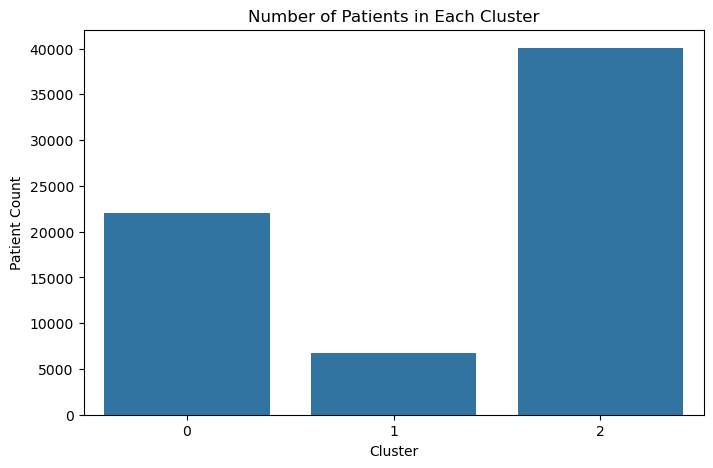

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Number of Patients in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Patient Count")

plt.show()

In [23]:
important_features = [
    "age",
    "BMI",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc"
]

cluster_profile[important_features]

,age,BMI,ap_hi,ap_lo,cholesterol,gluc
Cluster,,,,,,
0,55.17,31.79,139.20,87.86,1.81,1.51
1,51.76,26.74,127.68,82.11,1.37,1.20
2,51.72,25.23,119.53,77.70,1.12,1.08


# Cluster Interpretation

The clinical characteristics of each cluster were analyzed using the average values of important health indicators.

### Cluster 0 – High Risk

Patients in this cluster have the highest average BMI, blood pressure, cholesterol, glucose levels, and age, indicating the greatest cardiovascular risk.

### Cluster 1 – Moderate Risk

Patients in this cluster show moderate values across the major clinical indicators, representing an intermediate risk group.

### Cluster 2 – Low Risk

Patients in this cluster have the lowest average BMI, blood pressure, cholesterol, and glucose levels, suggesting the lowest cardiovascular risk.

Therefore, the clusters are interpreted as:

- Cluster 0 → High Risk
- Cluster 1 → Moderate Risk
- Cluster 2 → Low Risk

In [24]:
risk_mapping = {
    0: "High Risk",
    1: "Moderate Risk",
    2: "Low Risk"
}

df["Risk_Tier"] = df["Cluster"].map(risk_mapping)

df[["Cluster", "Risk_Tier"]].head()

,Cluster,Risk_Tier
0,2,Low Risk
1,0,High Risk
2,2,Low Risk
3,0,High Risk
4,2,Low Risk


In [26]:
risk_counts = df["Risk_Tier"].value_counts()

display(risk_counts)

Risk_Tier
Low Risk         40060
High Risk        21990
Moderate Risk     6698
Name: count, dtype: int64

In [27]:
risk_percentage = (
    df["Risk_Tier"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(risk_percentage)

Risk_Tier
Low Risk         58.27
High Risk        31.99
Moderate Risk     9.74
Name: proportion, dtype: float64

# Population Risk Dashboard

## Objective

This dashboard summarizes the distribution of patients across the identified risk tiers.

It provides visual insights into:

- Distribution of patients
- Clinical characteristics of each risk tier
- Comparison of important health indicators

These visualizations help healthcare professionals quickly understand the overall health profile of the patient population.

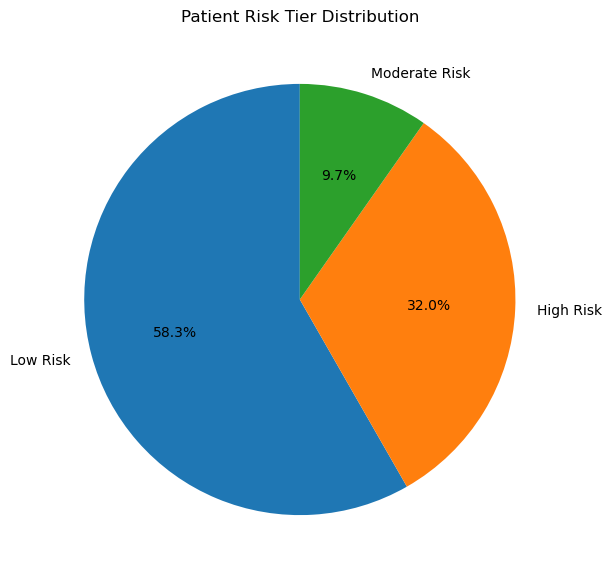

In [28]:
plt.figure(figsize=(7,7))

df["Risk_Tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Patient Risk Tier Distribution")

plt.ylabel("")

plt.show()

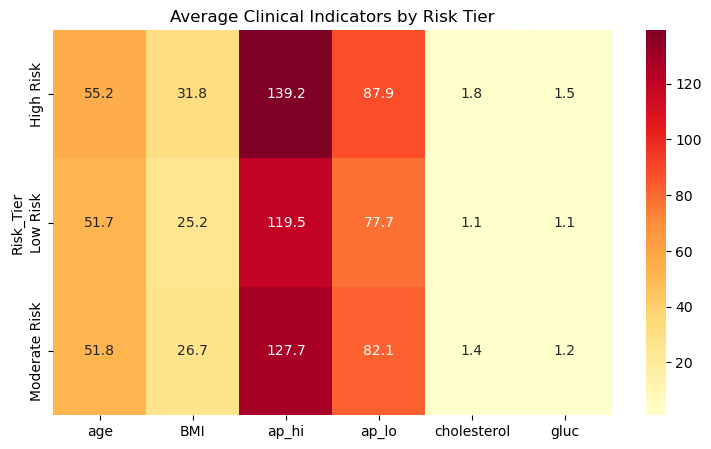

In [29]:
heatmap_data = (
    df.groupby("Risk_Tier")[
        [
            "age",
            "BMI",
            "ap_hi",
            "ap_lo",
            "cholesterol",
            "gluc"
        ]
    ]
    .mean()
)

plt.figure(figsize=(9,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".1f"
)

plt.title("Average Clinical Indicators by Risk Tier")

plt.show()

In [30]:
summary = (
    df.groupby("Risk_Tier")[
        [
            "age",
            "BMI",
            "ap_hi",
            "ap_lo",
            "cholesterol",
            "gluc"
        ]
    ]
    .mean()
    .round(2)
)

display(summary)

,age,BMI,ap_hi,ap_lo,cholesterol,gluc
Risk_Tier,,,,,,
High Risk,55.17,31.79,139.20,87.86,1.81,1.51
Low Risk,51.72,25.23,119.53,77.70,1.12,1.08
Moderate Risk,51.76,26.74,127.68,82.11,1.37,1.20


## Interpretation of Risk Tiers

The K-Means clustering algorithm successfully divided the patient population into three clinically meaningful groups.

### 🔴 High Risk

Patients in this group have:

- Highest average age
- Highest Body Mass Index (BMI)
- Highest systolic and diastolic blood pressure
- Highest cholesterol level
- Highest glucose level

These characteristics indicate a greater likelihood of cardiovascular disease and require closer medical attention.

---

### 🟡 Moderate Risk

Patients in this group have moderate values for all major clinical indicators.

Although healthier than the High Risk group, they still exhibit elevated cardiovascular risk factors and may benefit from lifestyle modifications and regular health monitoring.

---

### 🟢 Low Risk

Patients in this group have:

- Lowest BMI
- Lowest blood pressure
- Lowest cholesterol level
- Lowest glucose level

These patients represent the healthiest segment of the population and have the lowest overall cardiovascular risk among the three clusters.

---

### Conclusion

The clustering results demonstrate that K-Means successfully identified three distinct patient groups based solely on clinical and lifestyle characteristics without using the disease label (`cardio`).

These risk tiers can support preventive healthcare by helping medical professionals identify patients who may require early intervention.

In [31]:

validation = pd.crosstab(
    df["Risk_Tier"],
    df["cardio"],
    normalize="index"
) * 100

validation = validation.round(2)

validation.columns = ["No Disease (%)", "Disease (%)"]

display(validation)

,No Disease (%),Disease (%)
Risk_Tier,,
High Risk,26.55,73.45
Low Risk,63.15,36.85
Moderate Risk,53.55,46.45


# Gaussian Mixture Model (GMM)

## Objective

Gaussian Mixture Model (GMM) is a probabilistic clustering algorithm that assumes the data is generated from a mixture of Gaussian distributions.

Unlike K-Means, which assigns each patient to exactly one cluster, GMM estimates the probability that a patient belongs to each cluster.

This flexibility allows GMM to better model overlapping patient populations and more complex cluster shapes.

The same number of clusters (K = 3) is used to enable comparison with the K-Means model.

In [32]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

df["GMM_Cluster"] = gmm_labels

print("Gaussian Mixture Model trained successfully!")

print()

print(df["GMM_Cluster"].value_counts().sort_index())

Gaussian Mixture Model trained successfully!

GMM_Cluster
0    43979
1    18720
2     6049
Name: count, dtype: int64


In [33]:
gmm_profile = (
    df.groupby("GMM_Cluster")
      .mean(numeric_only=True)
      .round(2)
)

display(gmm_profile)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,Cluster
GMM_Cluster,,,,,,,,,,,,,,
0,52.97,1.00,161.39,72.44,125.87,80.90,1.38,1.23,0.0,0.02,0.80,0.49,27.89,1.29
1,52.84,2.00,169.84,77.08,127.91,82.24,1.32,1.21,0.0,0.05,0.80,0.51,26.69,1.29
2,51.79,1.87,169.37,77.19,128.07,82.15,1.39,1.22,1.0,0.30,0.84,0.47,26.89,0.99


In [34]:
gmm_score = silhouette_score(
    X_scaled,
    gmm_labels,
    sample_size=10000,
    random_state=42
)

print(f"GMM Silhouette Score: {gmm_score:.4f}")

GMM Silhouette Score: 0.1539


In [35]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Gaussian Mixture Model"
    ],
    "Silhouette Score": [
        max(silhouette_scores),
        gmm_score
    ]
})

display(comparison)

,Algorithm,Silhouette Score
0,K-Means,0.189181
1,Gaussian Mixture Model,0.153864


# Gaussian Mixture Model Results

## Cluster Distribution

The Gaussian Mixture Model divided the patients into three probabilistic clusters.

Unlike K-Means, GMM assigns patients based on probability distributions, allowing clusters to overlap and capture more complex data structures.

## Performance Evaluation

The Silhouette Score obtained by GMM was **0.1539**.

Compared to the K-Means score of **0.1892**, the GMM model produced less compact and less well-separated clusters.

## Interpretation

Although GMM is capable of modeling overlapping patient populations, the cardiovascular dataset appears to contain relatively compact groups after feature scaling.

As a result, the K-Means algorithm produced better-defined clusters and achieved a higher Silhouette Score.

## Conclusion

For this dataset, K-Means outperformed the Gaussian Mixture Model in terms of clustering quality and was selected as the preferred clustering algorithm for patient risk segmentation.

In [36]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Gaussian Mixture Model"],
    "Silhouette Score": [0.189181, 0.153864],
    "Ranking": [1, 2],
    "Remarks": [
        "Better cluster separation",
        "Lower cluster separation"
    ]
})

display(comparison)

,Algorithm,Silhouette Score,Ranking,Remarks
0,K-Means,0.189181,1,Better cluster separation
1,Gaussian Mixture Model,0.153864,2,Lower cluster separation


# Final Conclusion

## Project Summary

This project applied unsupervised machine learning techniques to identify hidden patient risk groups within a cardiovascular dataset.

Two clustering algorithms were implemented:

- K-Means Clustering
- Gaussian Mixture Model (GMM)

The optimal number of clusters was determined using the Elbow Method and the Silhouette Score, resulting in **K = 3**.

The identified clusters were interpreted as:

- 🟢 Low Risk
- 🟡 Moderate Risk
- 🔴 High Risk

Cluster validation using the original `cardio` label showed that the High Risk cluster contained the highest proportion of cardiovascular disease cases (73.45%), confirming that the clustering results are clinically meaningful.

A comparison between K-Means and GMM showed that K-Means achieved a higher Silhouette Score (0.1892) than GMM (0.1539), indicating better cluster separation for this dataset.

## Key Findings

- Three clinically meaningful patient risk groups were identified.
- High Risk patients exhibited higher BMI, blood pressure, cholesterol, glucose, and age.
- Low Risk patients showed healthier average clinical indicators.
- Validation with the original disease label confirmed the effectiveness of the clustering approach.
- K-Means outperformed the Gaussian Mixture Model based on the Silhouette Score.

## Conclusion

The results demonstrate that unsupervised learning can effectively segment patients into meaningful cardiovascular risk groups without using disease labels during training. These risk tiers can support healthcare professionals in early risk assessment, preventive healthcare planning, and targeted intervention strategies.